[' ', '`', "'", '.', '-', ',', '_', ':', '~', '"', '^', '!', '=', ';', '+', '<', '>', '/', '\\', '?', '7', 'c', 'l', 'v', 'L', 'i', 't', '(', ')', '*', 'r', '1', 'x', 'z', 'J', 'T', '|', '4', 'f', 'j', 'Y', '{', '}', 's', '[', ']', 'n', 'u', 'F', 'I', '2', '3', 'y', 'C', 'o', '5', 'a', 'e', 'V', 'Z', 'k', 'h', 'E', 'X', 'P', 'S', '9', '6', 'A', 'K', 'U', 'd', 'p', 'q', '&', 'b', 'm', 'w', 'H', 'G', 'O', '#', '8', 'D', 'R', '0', 'g', 'B', 'Q', '%', 'N', '$', 'M', '@', 'W']
95
(512, 512)
(102, 102)


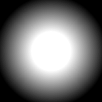

In [1]:
import sys
sys.path.append('../src')

from IPython.display import display, clear_output
from PIL import Image, ImageOps, ImageDraw, ImageFont, ImageChops
import matplotlib.pyplot as plt
import numpy as np

from palette.symbol2value import get_asciis, symbols_sorted
from image.processing import preprocess_img
from rendering.image import render_symbols_img
from converters.img_converter import ImgConverter
from converters.line_heuristics.utils import evaluate_symbol_arr, get_line_height
from converters.tile.bin_2d import Tile2Symb2dBin

# FONT = ImageFont.truetype("../fonts/OpenSans-Regular.ttf", 18)
FONT = ImageFont.truetype("../fonts/FiraCode-Regular.ttf", 18)

CHAR_SET = symbols_sorted(get_asciis(), FONT)
print(CHAR_SET)
print(len(CHAR_SET))
line_height = get_line_height(CHAR_SET, FONT) + 1
tile_converter = Tile2Symb2dBin(CHAR_SET, FONT)

IMG_PATH = "../imgs/irad_grad.bmp"
orig_img = Image.open(IMG_PATH).convert("L")
print(orig_img.size)
prep_img = preprocess_img(orig_img, 0.2, contrast=2.0)
print(prep_img.size)
display(prep_img)

[[' ', ' ', '_', 'g', 'g', 'g', '_', ' ', ' '], [' ', '@', '@', '@', '@', '@', '@', 'g', ' '], [' ', '@', '@', '@', '@', '@', 'W', 'W', '`'], [' ', '`', '^', 'M', 'M', 'M', '%', '^', ' '], [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']]
-14822.500672818147


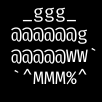

In [2]:
from converters.line_heuristics.greedy import GreedyLineSearch

line_converter = GreedyLineSearch(CHAR_SET, FONT)
res_arr = ImgConverter(line_converter).img2symbols(prep_img, line_height=line_height)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

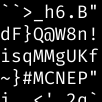

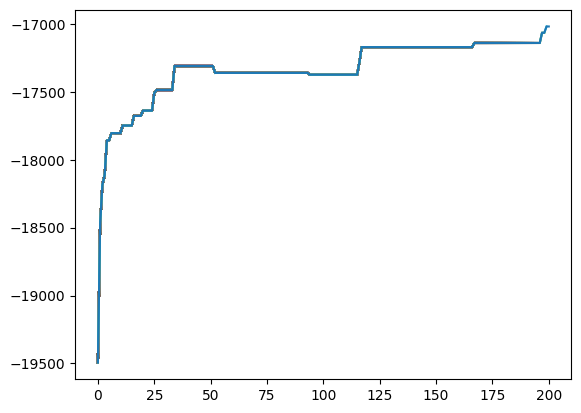

In [3]:
from converters.line_heuristics.random_search import RandomLineSearch

line_converter = RandomLineSearch(CHAR_SET, FONT, 1000)
res_history = []
for res_arr in ImgConverter(line_converter).img2symbols_lazy(prep_img, line_height=line_height, gens_per_step=5):
    res_history.append(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
    clear_output()
    plt.plot(res_history)
    display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

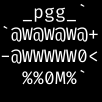

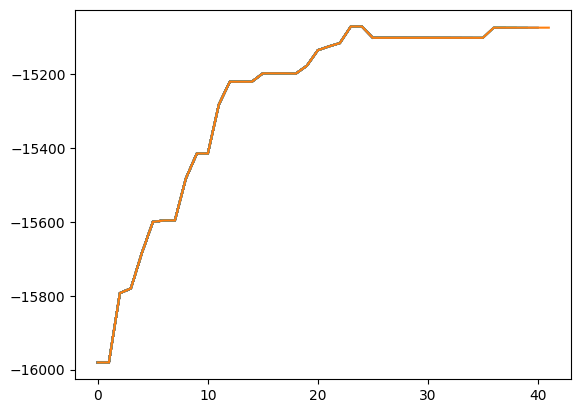

In [4]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch

line_converter =  HarmonyLineSearch(CHAR_SET, FONT, generations=200, pop_count=20,
                                    mem_rate=0.6, pa_rate=0.2, pa=len(CHAR_SET) // 4,
                                    tile_converter=tile_converter)
res_history = []
for res_arr in ImgConverter(line_converter).img2symbols_lazy(prep_img, line_height=line_height, gens_per_step=5):
    res_history.append(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
    clear_output()
    plt.plot(res_history)
    display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

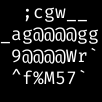

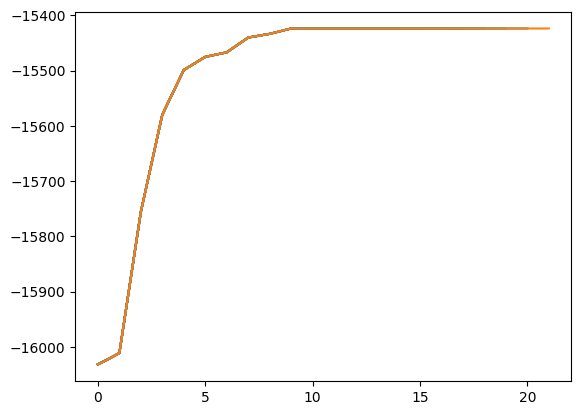

In [5]:
from converters.line_heuristics.genetic_search import GeneticLineSearch

line_converter =  GeneticLineSearch(CHAR_SET, FONT, generations=100, pop_count=50,
                                    tile_converter=tile_converter)
res_history = []
for res_arr in ImgConverter(line_converter).img2symbols_lazy(prep_img, line_height=line_height, gens_per_step=5):
    res_history.append(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
    clear_output()
    plt.plot(res_history)
    display(render_symbols_img(res_arr, FONT, wh=prep_img.size))


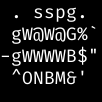

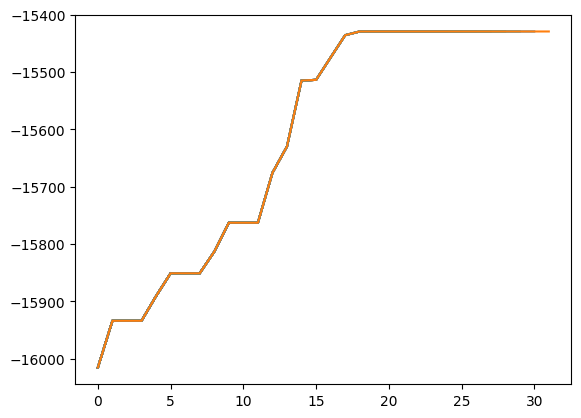

In [6]:
from converters.line_heuristics.pso_search import ParticleSwarmLineSearch

line_converter = ParticleSwarmLineSearch(CHAR_SET, FONT, generations=300, pop_count=8,
                                         innertion=1.5, cog_coeff=2.0, soc_coeff=2.5,
                                         tile_converter=tile_converter)
res_history = []
for res_arr in ImgConverter(line_converter).img2symbols_lazy(prep_img, line_height=line_height, gens_per_step=10):
    res_history.append(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
    clear_output()
    plt.plot(res_history)
    display(render_symbols_img(res_arr, FONT, wh=prep_img.size))
